In [209]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [210]:
dataset = fetch_20newsgroups()
X = np.array(dataset.data)
y = np.array(dataset.target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
print(dataset.target_names)
print(len(dataset.target_names))
print(X.shape, y.shape)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
20
(11314,) (11314,)
(9051,) (2263,) (9051,) (2263,)


In [211]:
i = 580
print(X_test[i])
print(dataset.target_names[y_test[i]])

Organization: University of Illinois at Chicago, academic Computer Center
From: Jason Kratz <U28037@uicvm.uic.edu>
Subject: Re: What to do if you shoot somebody
 <1993Apr18.061532.3288@uoft02.utoledo.edu>
Lines: 40

In article <1993Apr18.061532.3288@uoft02.utoledo.edu>,
steiner@jupiter.cse.utoledo.edu (Jason 'Think!' Steiner) says:
>
>Jason Kratz (U28037@uicvm.uic.edu) writes:
>>
>> Say you're in a situation where you have to pull a gun on somebody.
>>  You give them a chance to get away but they decided to continue in
>> their action anyway and you end up shooting and killing them.  My
>> question is what do you do?  Should you stay and wait for the cops
>> or should you collect your brass (if you're using a semi-auto) and
>> get out of there (provided of course you don't think that you have
>> been seen)?  What kind of laws are on the books regarding this type
>> of situation?  What would be the most likely thing to happen to you
>> if you stayed and waited and it was a first offense

In [212]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=None,
    norm="l2",
)
query = "Tell me about cars"
train_matrix = vectorizer.fit_transform(X_train)
test_matrix = vectorizer.transform(X_test)
query_vector = vectorizer.transform([query])
similarities = cosine_similarity(query_vector, train_matrix)[0]
i = similarities.argmax()
print(train_matrix.shape)
print(i)
print(X_train[i])
print(dataset.target_names[y_train[i]])

(9051, 117598)
843
From: gaia@carson.u.washington.edu (I/We are Gaia)
Subject: Re: Plymouth Sundance/Dodge Shadow experiences?
Organization: University of Washington, Seattle
Lines: 115
Distribution: usa
NNTP-Posting-Host: carson.u.washington.edu

In article <oprsfnx.735015349@gsusgi1.gsu.edu> oprsfnx@gsusgi2.gsu.edu (Stephen F. Nicholas) writes:
>daubendr@NeXTwork.Rose-Hulman.Edu (Darren R Daubenspeck) writes:
>
>
>>> they are pretty much junk, stay away from them.  they will be replaced next
>>> year with all new models.  
>
>
>>Junk?  They've made the C&D lists for years due to their excellent handling and  
>>acceleration.  They have been around since about, oh, 85 or 86, so they're not  
>>the newest on the lot, and mileage is about five to eight MPG under the class  
>>leader.  You can get into a 3.0 L v-6 (141 hp) Shadow for $10~11K (the I-4  
>>turbo a bit more), and a droptop for $14~15K.  
>
>
> As an ex-Fleet Mgr. of 3000 cars, they were amoung the most trouble free of
>all 

In [213]:
model = LogisticRegression(max_iter=2000)
print(train_matrix.shape, y_train.shape)
model.fit(train_matrix, y_train);

(9051, 117598) (9051,)


In [214]:
y_pred = model.predict(test_matrix)
score = accuracy_score(y_test, y_pred)
print(score)

0.8912947414935926


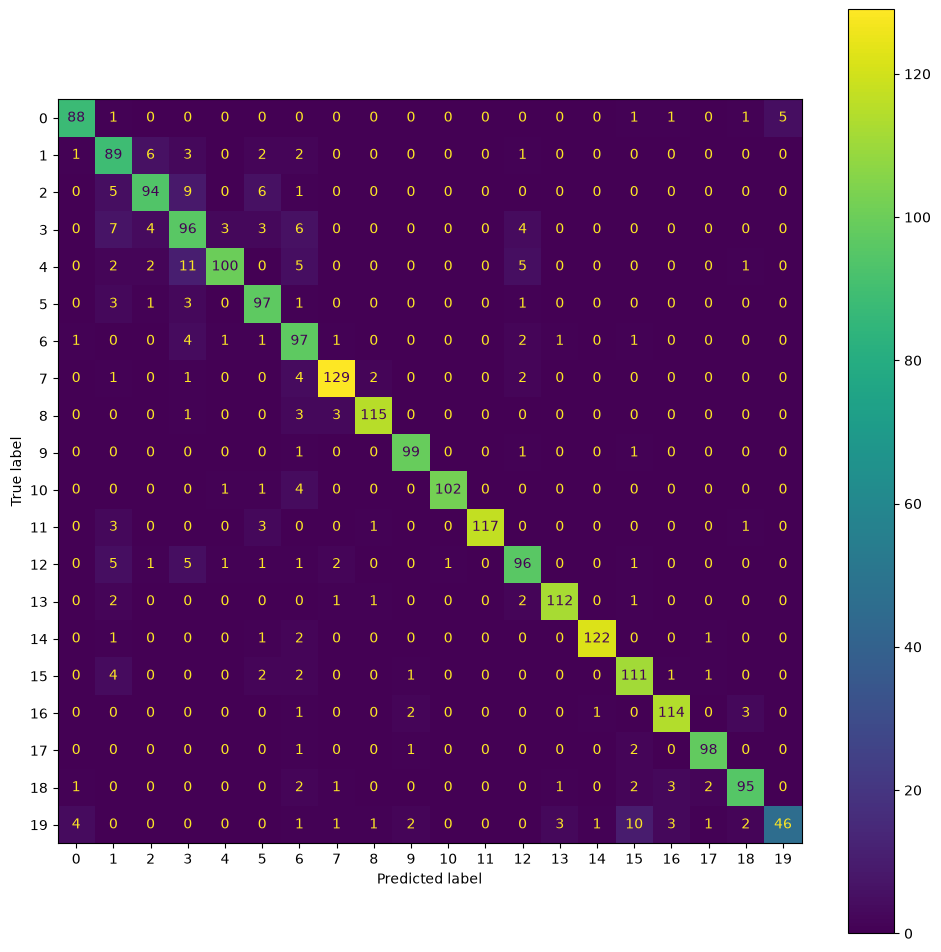

In [215]:
cm = confusion_matrix(y_test, y_pred)
fix, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.show()

In [216]:
mask = y_test != y_pred
X_misclassified = X_test[mask]
y_misclassified_pred = y_pred[mask]
y_misclassified_actual = y_test[mask]
print(X_misclassified.shape)
print(mask)

(246,)
[ True False False ... False False False]


In [ ]:
idx = [0,1,2,3,4]
for i in idx:
    print(X_misclassified[i])
    print(f"prediction: {dataset.target_names[y_misclassified_pred[i]]}")
    print(f"actual: {dataset.target_names[y_misclassified_actual[i]]}")
    print("----------")

From: rrn@po.CWRU.Edu (Robert R. Novitskey)
Subject: CYCLONE AND TEMPEST?????
Article-I.D.: usenet.1pskav$qtu
Reply-To: rrn@po.CWRU.Edu (Robert R. Novitskey)
Organization: Case Western Reserve University, Cleveland, OH (USA)
Lines: 10
NNTP-Posting-Host: thor.ins.cwru.edu


Could someone please post any info on these systems.

Thanks.
BoB
-- 
---------------------------------------------------------------------- 
Robert Novitskey | "Pursuing women is similar to banging one's head
rrn@po.cwru.edu  |  against a wall...with less opportunity for reward" 
---------------------------------------------------------------------- 

prediction: comp.sys.ibm.pc.hardware
actual: comp.sys.mac.hardware
----------
From: L.H.Wood@lut.ac.uk
Subject: An 8051 simulator - is example code available?
Reply-To: L.H.Wood@lut.ac.uk (Lloyd Wood)
Organization: Loughborough University, UK.
Lines: 25

Hello world,
 
I'm attempting to write an 8051 simulator on an IBM PC for teaching
purposes, so that first-year elec

: 

covered: preprocessing + TF-IDF + text classification
dataset: 20 Newsgroups
model: TfidfVectorizer + LogisticRegression
metric: accuracy ~= 0.89
main bugs: refit vectorizer on test data; mixed filtered and unfiltered indices during error inspection